### Heart Disease Predictor

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

# Load the dataset
heart_disease_data = pd.read_csv('./dataset/heart.csv')
heart_disease_data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [90]:
heart_disease_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [91]:
heart_disease_data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [92]:
heart_disease_data.shape

(918, 12)

In [93]:
heart_disease_data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [94]:
for col in heart_disease_data.columns:
    print(col, heart_disease_data[col].nunique())

Age 50
Sex 2
ChestPainType 4
RestingBP 67
Cholesterol 222
FastingBS 2
RestingECG 3
MaxHR 119
ExerciseAngina 2
Oldpeak 53
ST_Slope 3
HeartDisease 2


In [95]:
heart_disease_data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [96]:
zero_cols = ['RestingBP', 'Cholesterol']
print((heart_disease_data[zero_cols] == 0).sum())

RestingBP        1
Cholesterol    172
dtype: int64


In [97]:
heart_disease_data[zero_cols] = heart_disease_data[zero_cols].replace(0, np.nan)
heart_disease_data.isnull().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

In [98]:
zero_cols = ['RestingBP', 'Cholesterol']
print((heart_disease_data[zero_cols] == 0).sum())

RestingBP      0
Cholesterol    0
dtype: int64


In [99]:
heart_disease_data['ExerciseAngina'].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

<Axes: xlabel='HeartDisease', ylabel='count'>

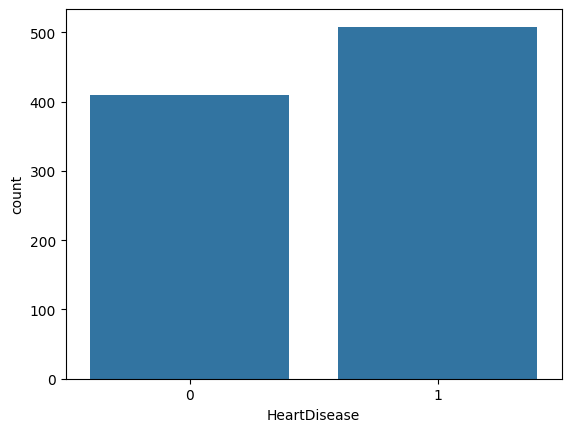

In [100]:
import seaborn as sns
sns.countplot(x='HeartDisease', data=heart_disease_data)

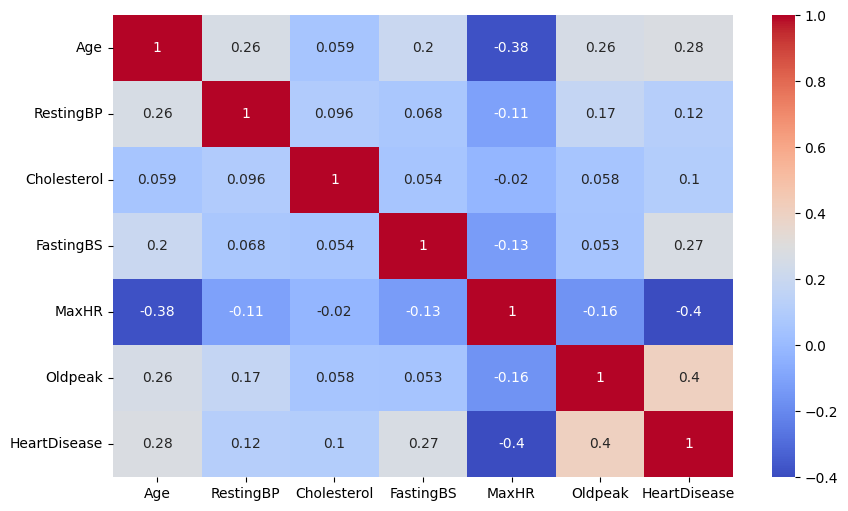

In [101]:
plt.figure(figsize=(10,6))
sns.heatmap(heart_disease_data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [102]:
heart_disease_data.isnull().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

In [103]:
heart_disease_data.duplicated().sum()

np.int64(0)

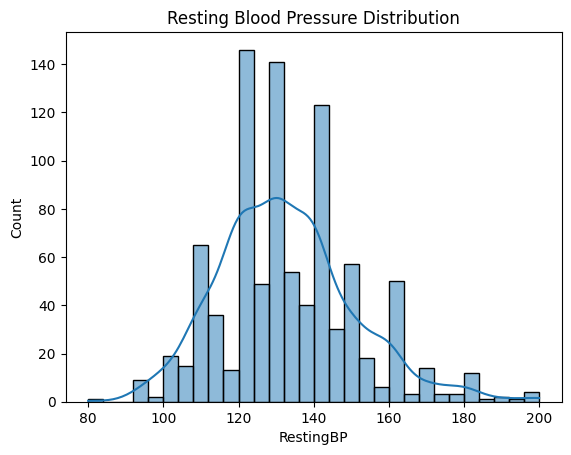

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(heart_disease_data['RestingBP'], kde=True)

plt.title("Resting Blood Pressure Distribution")
plt.show()

In [105]:
heart_disease_data['RestingBP'].describe()

count    917.000000
mean     132.540894
std       17.999749
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestingBP, dtype: float64

In [106]:
heart_disease_data['Cholesterol'].describe()

count    746.000000
mean     244.635389
std       59.153524
min       85.000000
25%      207.250000
50%      237.000000
75%      275.000000
max      603.000000
Name: Cholesterol, dtype: float64

In [107]:
heart_disease_data['RestingBP'] = heart_disease_data['RestingBP'].fillna(130)
heart_disease_data['Cholesterol'] = heart_disease_data['Cholesterol'].fillna(237)
heart_disease_data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [108]:
heart_disease_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.0,54.0,60.0,77.0
RestingBP,918.0,132.538126,17.990127,80.0,120.0,130.0,140.0,200.0
Cholesterol,918.0,243.204793,53.401297,85.0,214.0,237.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.0,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.0,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.0,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.0,1.0,1.0,1.0


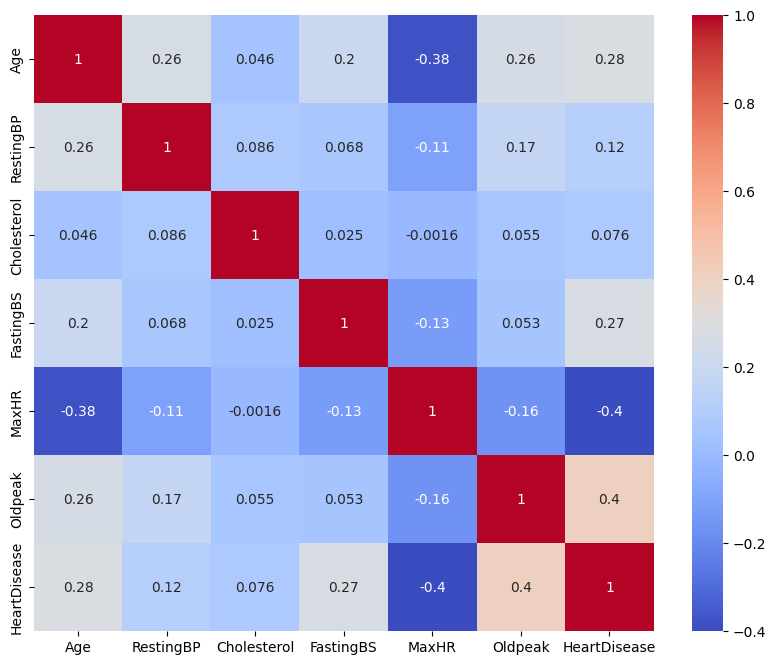

In [109]:
plt.figure(figsize=(10,8))
sns.heatmap(heart_disease_data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [110]:
heart_disease_encoded = pd.get_dummies(heart_disease_data, drop_first=True, dtype=int)

# Now check your head
heart_disease_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150.0,195.0,0,122,0.0,0,1,0,1,0,1,0,0,0,1


In [111]:
heart_disease_encoded.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

In [112]:
heart_disease_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    float64
 2   Cholesterol        918 non-null    float64
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    int64  
 7   Sex_M              918 non-null    int64  
 8   ChestPainType_ATA  918 non-null    int64  
 9   ChestPainType_NAP  918 non-null    int64  
 10  ChestPainType_TA   918 non-null    int64  
 11  RestingECG_Normal  918 non-null    int64  
 12  RestingECG_ST      918 non-null    int64  
 13  ExerciseAngina_Y   918 non-null    int64  
 14  ST_Slope_Flat      918 non-null    int64  
 15  ST_Slope_Up        918 non-null    int64  
dtypes: float64(3), int64(13)
memory usage

### Training the model

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Define features and target
X = heart_disease_encoded.drop('HeartDisease', axis=1)
y = heart_disease_encoded['HeartDisease']

# 2. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [114]:
X

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,1,1,0,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,1,1,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,0,0,0,0,1,0,1,1,0
4,54,150.0,195.0,0,122,0.0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,0,0,1,1,0,0,1,0
914,68,144.0,193.0,1,141,3.4,1,0,0,0,1,0,0,1,0
915,57,130.0,131.0,0,115,1.2,1,0,0,0,1,0,1,1,0
916,57,130.0,236.0,0,174,0.0,0,1,0,0,0,0,0,1,0


<Axes: >

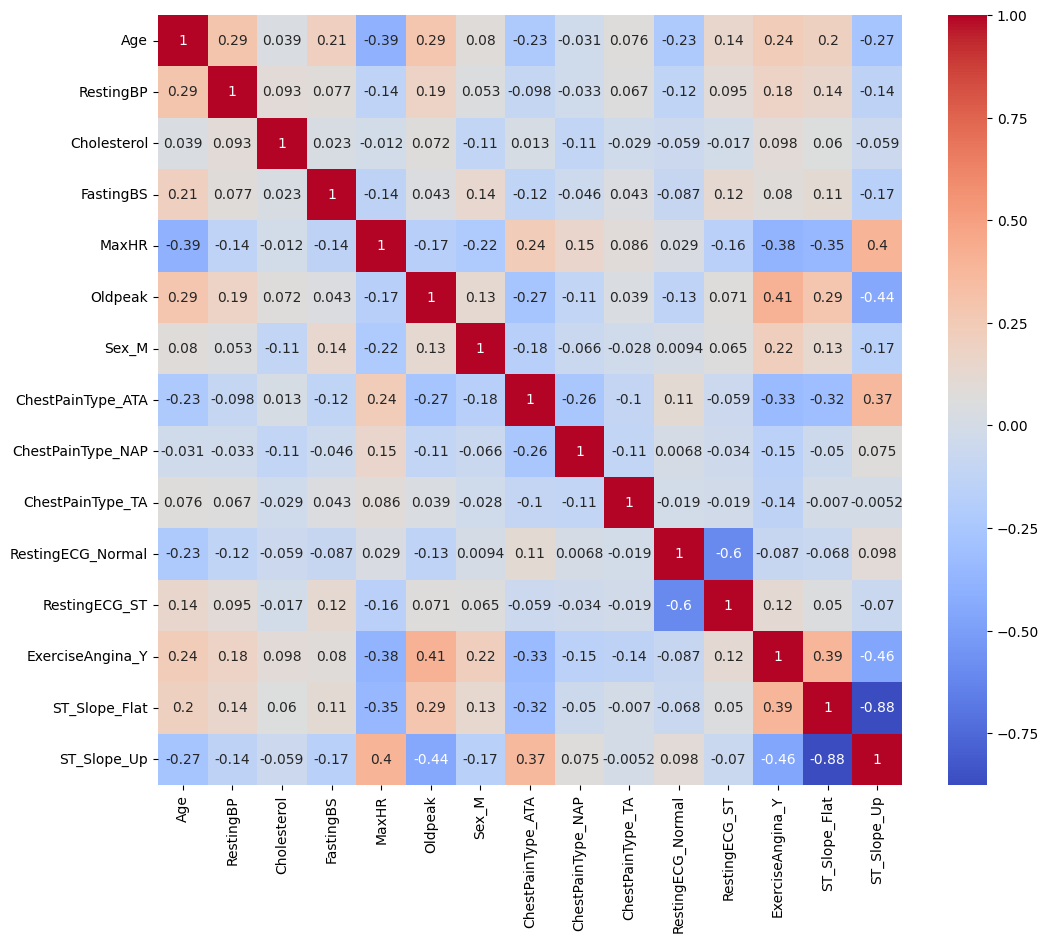

In [115]:
## Check for multicollinearity
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [116]:
import joblib

def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: 
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

corr_features = correlation(X_train, 0.85)
print("Highly correlated features to drop:", corr_features)

X_train = X_train.drop(corr_features, axis=1)
X_test = X_test.drop(corr_features, axis=1)

joblib.dump(X_train.columns.tolist(), 'features.pkl')

Highly correlated features to drop: {'ST_Slope_Up'}


['features.pkl']

In [117]:
# 3. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [118]:
X_train_scaled


array([[-1.24506731, -0.74559246, -0.07753369, ..., -0.48762079,
        -0.83846064, -1.03325003],
       [-1.8862362 , -0.18250483, -0.69074241, ..., -0.48762079,
        -0.83846064, -1.03325003],
       [ 0.25099346,  0.94367043, -0.6116187 , ..., -0.48762079,
         1.19266183,  0.96781995],
       ...,
       [ 0.67843939, -0.18250483,  0.17961836, ..., -0.48762079,
         1.19266183, -1.03325003],
       [ 0.67843939,  1.05628795, -0.13687647, ...,  2.05077394,
         1.19266183, -1.03325003],
       [-1.45879027,  0.94367043,  2.92916715, ..., -0.48762079,
        -0.83846064,  0.96781995]], shape=(734, 14))

In [119]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

In [120]:
print("--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Model Performance ---
Accuracy Score: 85.33%

Confusion Matrix:
[[68  9]
 [18 89]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83        77
           1       0.91      0.83      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



In [121]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) 
rf_y_pred = rf_model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_y_pred) * 100:.2f}%")

Random Forest Accuracy: 86.41%


In [122]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred), accuracy_score(y_test, rf_y_pred)]
})
print(results)

                 Model  Accuracy
0  Logistic Regression  0.853261
1        Random Forest  0.864130


In [123]:
# Check accuracy on Training data
train_pred = rf_model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Check accuracy on Testing data
test_acc = accuracy_score(y_test, rf_y_pred)

print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Testing Accuracy: {test_acc*100:.2f}%")

Training Accuracy: 100.00%
Testing Accuracy: 86.41%


In [124]:
cm = confusion_matrix(y_test, rf_y_pred)

specificity = cm[0,0] / (cm[0,0] + cm[0,1])
sensitivity = cm[1,1] / (cm[1,1] + cm[1,0])

print(f"Sensitivity (Recall): {sensitivity*100:.2f}%")
print(f"Specificity: {specificity*100:.2f}%")

Sensitivity (Recall): 88.79%
Specificity: 83.12%


In [125]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)

print(f"Cross-Validation Mean Score: {cv_scores.mean()*100:.2f}%")
print(f"Standard Deviation of Scores: {cv_scores.std()*100:.2f}%")

Cross-Validation Mean Score: 86.37%
Standard Deviation of Scores: 1.88%


C:\Users\bathi\AppData\Local\Temp\ipykernel_40912\3749106684.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=metrics, y=values, palette='magma')


Text(0, 0.5, 'Percentage (%)')

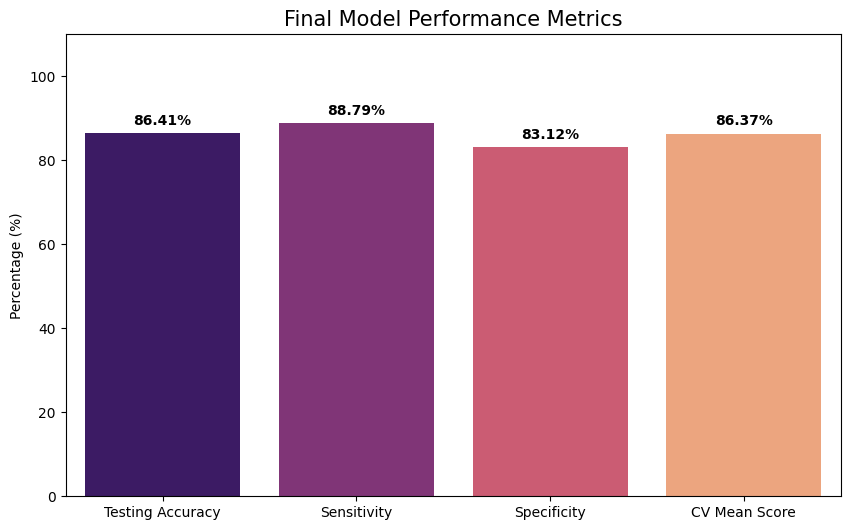

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for the summary
metrics = ['Testing Accuracy', 'Sensitivity', 'Specificity', 'CV Mean Score']
values = [86.41, 88.79, 83.12, 86.37]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=metrics, y=values, palette='magma')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), 
                textcoords = 'offset points', fontweight='bold')

plt.ylim(0, 110)
plt.title('Final Model Performance Metrics', fontsize=15)
plt.ylabel('Percentage (%)')

([<matplotlib.axis.YTick at 0x20300a1f110>,
 [Text(0, 0.5, 'Healthy'), Text(0, 1.5, 'Heart Disease')])

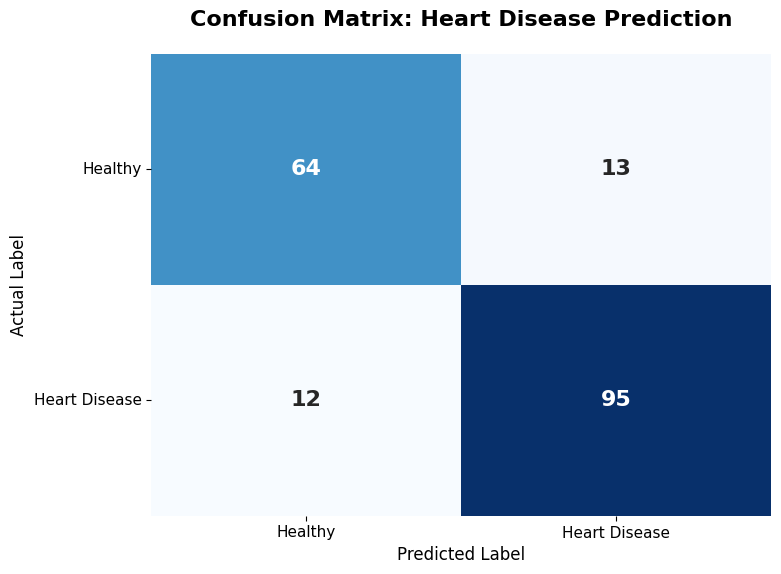

In [127]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 16, "weight": "bold"})

# Labeling the plot
plt.title('Confusion Matrix: Heart Disease Prediction', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.xticks([0.5, 1.5], ['Healthy', 'Heart Disease'], fontsize=11)
plt.yticks([0.5, 1.5], ['Healthy', 'Heart Disease'], fontsize=11, rotation=0)

### Save Best Model

In [ ]:
import joblib

# Save your existing model and scaler
joblib.dump(rf_model, 'heart_disease_model.pkl')

print("Model and Scaler saved successfully using joblib!")

Model and Scaler saved successfully using joblib!
